In [142]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom
import pandas as pd

Zadanie 9

Średnia empiryczna: 10.02
Średnia teoretyczna: 10.00


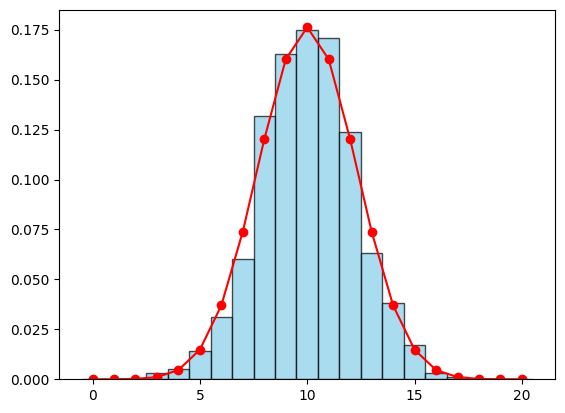

In [143]:
# 0 = Reszka, 1 = Orzeł
tosses = np.random.binomial(n=1, p=0.5, size=(20,1000))
tosses_o = np.sum(tosses, axis=0)
tosses_o_avg = np.mean(tosses_o)
theoretical_avg = 20 * 0.5
print(f"Średnia empiryczna: {tosses_o_avg:.2f}")
print(f"Średnia teoretyczna: {theoretical_avg:.2f}")

l_orlow = np.arange(0, 21)
pmf_values = binom.pmf(l_orlow, n=20, p=0.5)



plt.hist(tosses_o, bins=range(22), density=True, color='skyblue', edgecolor='black', alpha=0.7, align='left')
plt.plot(l_orlow, pmf_values, 'ro-', label='Teoretyczne PMF (binom.pmf)')

Zadanie 10

In [144]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=';')
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


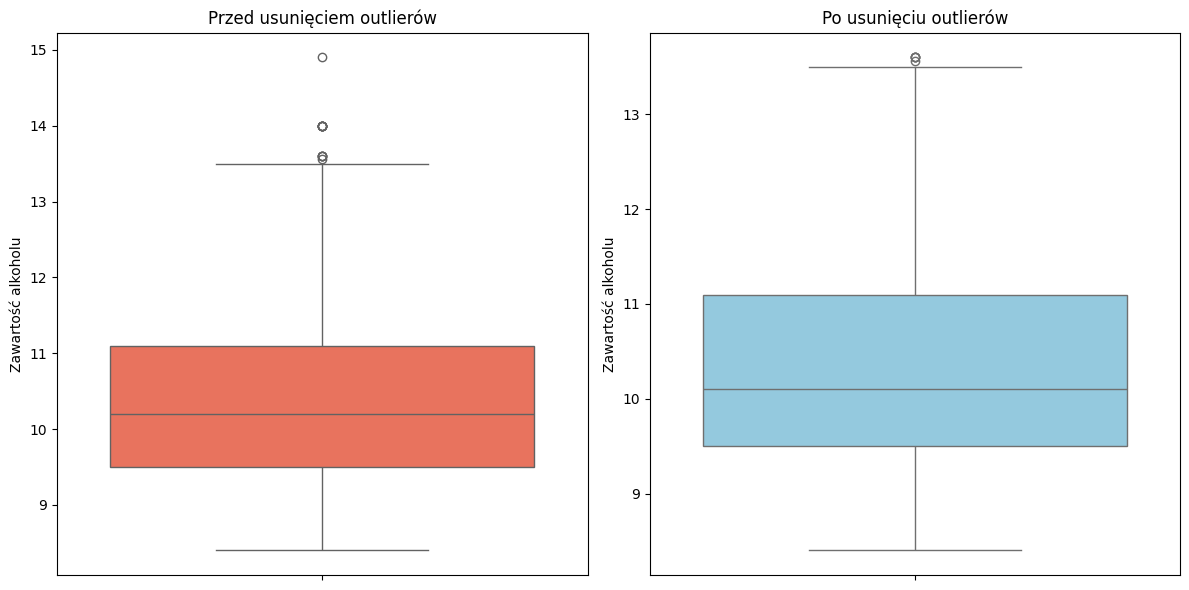

In [145]:
wine['z-score'] = (wine['alcohol'] - wine['alcohol'].mean()) / wine['alcohol'].std()
wine_out_drop = wine.copy()
wine_out_drop = wine_out_drop[abs(wine_out_drop['z-score']) < 3]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(y=wine['alcohol'], ax=axes[0], color='tomato')
axes[0].set_title('Przed usunięciem outlierów')
axes[0].set_ylabel('Zawartość alkoholu')

# Wykres po usunięciu
sns.boxplot(y=wine_out_drop['alcohol'], ax=axes[1], color='skyblue')
axes[1].set_title('Po usunięciu outlierów')
axes[1].set_ylabel('Zawartość alkoholu')

plt.tight_layout()
plt.show()

In [146]:
wine['alcohol'].describe()

count    1599.000000
mean       10.422983
std         1.065668
min         8.400000
25%         9.500000
50%        10.200000
75%        11.100000
max        14.900000
Name: alcohol, dtype: float64

In [147]:
wine_out_drop['alcohol'].describe()

count    1591.000000
mean       10.404431
std         1.035413
min         8.400000
25%         9.500000
50%        10.100000
75%        11.100000
max        13.600000
Name: alcohol, dtype: float64